In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm 

# $$\text{What is this project?}$$ 
Known as the Erdős–Rényi model(s), Paul Erdős and Alfréd Rényi introduced two graph models starting in 1959: the $G(n, M)$ and $G(n, p)$ model. This project will be focusing on the $G(n, p)$ model. This model is important because of its rigorous study of randomly formed networks, and is a foundational topic for network science, probability theory, combinatorics, and graph algorithms.

## What is the $G(n, p)$ model?
The $G(n, p)$ model is a graph constructed by connecting labeled $n$ nodes randomly. Each edge is included in the graph with probability $p$. The probability for generating each graph with $n$ nodes and $M$ edges is: $$p^m(1-p)^{\binom{n}{2} - M}$$

Imagine $p$ as a weighting function: as $p$ increases from 0 to 1, the model becomes more and more likely to include graphs with more edges and less and less likely to include graphs with fewer edges. When $p$ is very small, the graph consists mostly of isolated nodes and tiny components. However, around a critical threshold $p \approx \frac{1}{n}$, a connected component appears. 

A famous discovery in random graphs is graphs undergoing sharp transitions, as described above. These are analogous to phase transitions in physics (e.g., water boiling or freezing). As such, these discoveries can show complex global behaviors emerging from simple random local rules. 

The random Erdős–Rényi models provide a baseline (null hypothesis) for real networks, like:
- Internet topology
- Social networks
- Communication systems
- Neural networks

And more, which are typically not random and can be studied using the behaviors of the Erdős–Rényi random graphs. 

In [5]:
def draw_graph(G, title=""):
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=500,
        edge_color='gray'
    )
    plt.title(title)
    plt.show()

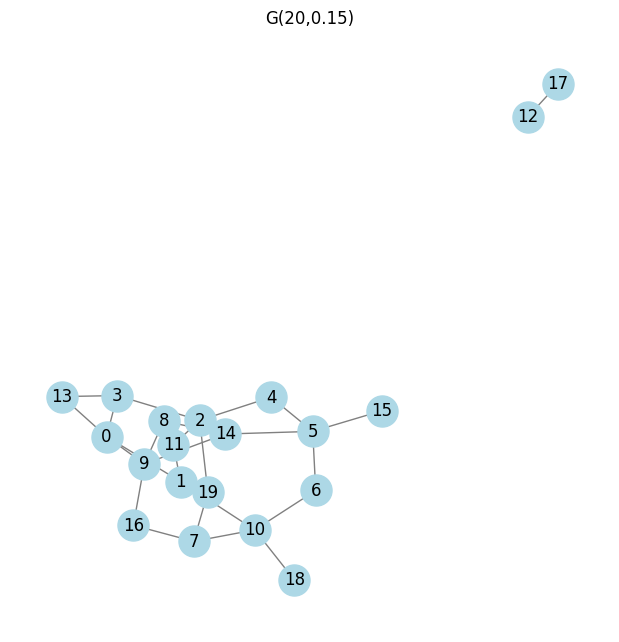

In [6]:
n = 20
p = 0.15

G = nx.erdos_renyi_graph(n, p)

draw_graph(G, f"G({n},{p})")

# $$\text{What Are The Goals For This Project?}$$
- The phase transition in the Erdős–Rényi is a fundamental topic, which occurs roughly at $p \approx \frac{1}{n}$. Part of this project will be tackling why $\frac{1}{n}$ is such a critical threshold. We can simulate the appearance of giant components past the $\frac{1}{n}$ threshold. Furthermore, we can use modern technology (coding and AI) to help recreate the discoveries of Paul Erdős and Alfréd Rényi in the late 50s into the 60s.

- Connectivity or Connectedness is an important topic within this project, which also produces a beautiful result in the connectivity threshold. At $p = \frac{\log{n}}{n}$, there is a sharp change in which almost every graph is connected, whereas graphs are almost surely disconnected below the threshold. 


# $$\text{Core Understandings For This Project}$$
The $G(n, p)$ model is fundamentally probabilitic. 

There are $\binom{n}{2} = \frac{n(n-1)}{2}$ possible total edges, with each edge acting as a Bernoulli random variable:
- Edge exists = 1 with probability $p$
- Edge is absent = 0 with probability $1-p$

*A Bernoulli random variable is one with exactly two possible outcomes: 1 (success), or 0 (failure)*

The total number of edges follows:
$$|E| \sim \text{Binomial}(\binom{n}{2}, p)$$
From this, many things follow:
- The expected number of edges:

$\mathbb{E}[|E|] = p \binom{n}{2}$

- The expected degree of a node:

$\mathbb{E}[\text{deg}(v)] = p(n-1)$

- Variance and Standard Deviation
- Concentration behavior

## $$\text{Graph Theory}$$
There are a few topics in Graph Theory needed to understand this project.

### What is a graph?
A graph is a mathematical object:
$$G = (V, E)$$
Where:
- $V$ = set of vertices (or nodes)
- $E$ = set of edges (or connections)

**Example:** each vertex is a person, and edges are their friendships.

The $G(n, p)$ model uses undirected graphs, which are non directional. Specifically:

If an edge $(u,v)$ exists, then:
- $u$ connects to $v$
- $v$ connects to $u$

But there is no direction, just a connection.

There are also a few assumptions for the Erdos-Renyi model:
- **No self loops**: There are no edges from a node to itself.
- **No multiple edges**: There exists at most one edges between two vertices. 

Some more things to know:
### **2. Adjacency Matrix**: a graph can be stored as a matrix. For $n$ vertices:
$$A_{ij} = \begin{cases} 
1 \text{ if edge exists} \\ 
0 \text{ otherwise}
\end{cases}$$
Example:
$$A = \begin{pmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{pmatrix}$$
Means:
- node 1 connected to 2
- node 2 connected to 3

This relates to:
- Shortest paths
- Eigenvalues
- connectivity
- clustering
- spectral methods

### **3. Paths**
A path is a sequence of connected vertices.

Example:
$$A \rightarrow B \rightarrow D \rightarrow F$$
The length of a path is the number of edges traversed. The above path has a length of 3. 

This relates to:
- Reachability
- Information flow
- Graph distances
- network efficiency

### **4. Connected Graphs**
A graph is connected if every pair of vertices has a path between them. It can be also thought of as every node being reachable, and a disconnected graph being one that has at least one node that is isolated. 

In the Erdős–Rényi Graphs, connectivity is a central result; as $p$ increases, isolated nodes decrease and disconnected components merge, creating a fully connected graph. There is a threshold near $p \approx \frac{\log{n}}{n}$.

**4.1 Connected Components (in undirected graphs)**
Connected components are maximal subgraphs within a graph where every node is reachable from every other node. A single node is also a connected component. Simple put, a connected component is the largest subgraph that cannot be within another subgraph, assuming the graph is not fully connected and contains proper subgraphs. 

Think of connected components as islands within the graph.

For example, if a graph is split into a group of 7 nodes, a group of 2 nodes, and a single isolated node, then it has 3 connected components. 

**4.1.1 Giant Components**
A giant component is a connected component of a random graph that contains a significant fraction of the entire graph's vertices. For example, when $p \approx \frac{1}{n}$, a giant component forms containing a positive fraction of all vertices. 

### **5. Trees**
A Tree in graph theory is connected and does not have any loops and is not closed. In other words, there is exactly one unique edge between two vertices. Note that a tree with $n$ vertices will subsequently have $n-1$ edges. 

Why do trees matter? Sparse local Erdős–Rényi graphs resemble trees, like around $p = \frac{c}{n}$ for a small constant $c$. 

### **6. Cycles**
A cycle, like the alternate possibility of trees, is a closed loop.

Example:
$$A \rightarrow B \rightarrow C \rightarrow A$$

Why do cycles matter? Cycles indicate:
- Redundancy
- Robustness
- Clustering
- Non-tree structures

**6.1 Triangle Cycles**
Any three points on a plane that do not all lie in a straight line create a triangle, which will be easy to create in trees. The expected number of triangles is: $$\binom{n}{3}p^3$$


### **7. Diameter**
Diameter is the longest shortest path between any pair of vertices in a connected graph. This can be split into two concepts:
- Distance: the length of the shortest path (number of edges) between two specific vertices
- Eccentricity: the maximum distance from a single vertex to any other vertex in the graph

Then, the diameter is the maximum eccentricity out of all vertices in the graph. Think of it as two points on a graph that are farthest apart out of all possible points, then finding the most efficient path to connect them.


Erdős–Rényi graphs often show short path lengths. Distances often scale along the lines of $\frac{\log{n}}{\log{np}}$, for example.

### **8. Clustering Coefficient**
The clustering coefficient measures how likely neighbors of a node connect to each other.

For example, if A is connected to B and A is connected to C, the clustering coefficient relates to the likelihood of B connecting to C.

In the Erdős–Rényi $G(n,p)$ model, clustering coefficient is just $p$, which is very simple and much lower than real-world networks. 

### **9. Density**
Graph density measures how full the graph is. With a maximum possible edges $\binom{n}{2}$, the density is $\frac{|E|}{\binom{n}{2}}$.

For Erdős–Rényi, the expected density is roughly $p$.



### **10. Degree**: like seen above, the degree of a vertex $\text{deg}(v)$ is the number of edges connected to it. 

For example, if a node A connects to B, C, and D, then $\text{deg}(A) = 3$. 

Degree helps tell how connected the nodes are, network density, likelihood of giant components, and robustness. 

For a fixed node: $\text{deg}(v) \sim \text{Binomial}(n-1, p)$ (the node independently tries to connect to every other node).

As shown above, the expected degree: $\mathbb{E}[\text{deg}(v)] = p(n-1)$

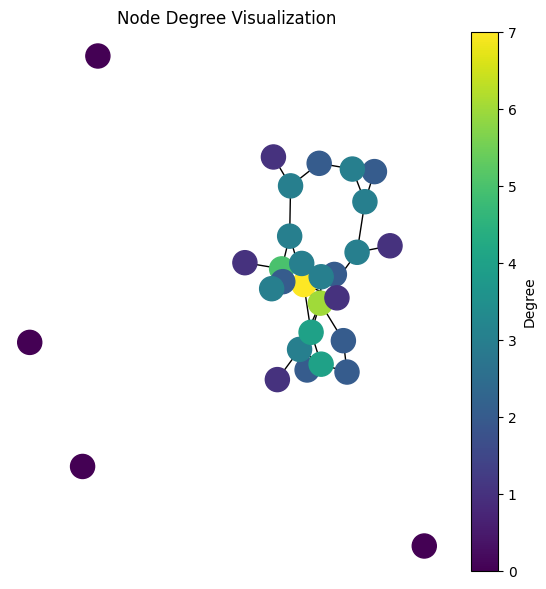

In [7]:
n = 30
p = 0.12

G = nx.erdos_renyi_graph(n, p)

degrees = [G.degree(v) for v in G.nodes()]

plt.figure(figsize=(7,7))
pos = nx.spring_layout(G, seed=42)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=degrees,
    cmap='viridis',
    node_size=300
)

nx.draw_networkx_edges(G, pos)
plt.colorbar(nodes, label="Degree")
plt.title("Node Degree Visualization")
plt.axis('off')
plt.show()

In [15]:
def generate_graph(n, p):
    return nx.erdos_renyi_graph(n, p)

In [16]:
def giant_component_fraction(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / G.number_of_nodes()

This returns: $$\frac{|C_{max}|}{n}$$
Or, the fraction of nodes in the giant component.

In [17]:
def is_connected(G):
    return nx.is_connected(G)

In [18]:
from networkx.algorithms import approximation as approx

cycle = approx.traveling_salesman_problem(G, cycle=True)

NameError: name 'G' is not defined

In [ ]:
def monte_carlo(n, p_values, trials=100):

    giant_results = []
    connected_results = []
    dirac_results = []

    for p in tqdm(p_values):

        giant_sizes = []
        connected_count = 0
        dirac_count = 0

        for _ in range(trials):

            G = nx.erdos_renyi_graph(n, p)

            # Giant component
            largest_cc = max(nx.connected_components(G), key=len)
            giant_sizes.append(len(largest_cc) / n)

            # Connectivity
            if nx.is_connected(G):
                connected_count += 1

            # Dirac condition
            min_degree = min(dict(G.degree()).values())
            if min_degree >= n / 2:
                dirac_count += 1

        giant_results.append(np.mean(giant_sizes))
        connected_results.append(connected_count / trials)
        dirac_results.append(dirac_count / trials)

    return giant_results, connected_results, dirac_results

In [ ]:
def plot_results(p_values, giant, connected, dirac):

    plt.figure(figsize=(10,6))

    plt.plot(p_values, giant, label="Largest Component Fraction")
    plt.plot(p_values, connected, label="Connected Probability")
    plt.plot(p_values, dirac, label="Dirac Condition Probability")

    plt.xlabel("p")
    plt.ylabel("Probability / Fraction")
    plt.title("Phase Transitions in G(n,p)")
    plt.legend()

    plt.grid(True)
    plt.show()

100%|██████████| 50/50 [00:08<00:00,  5.98it/s]


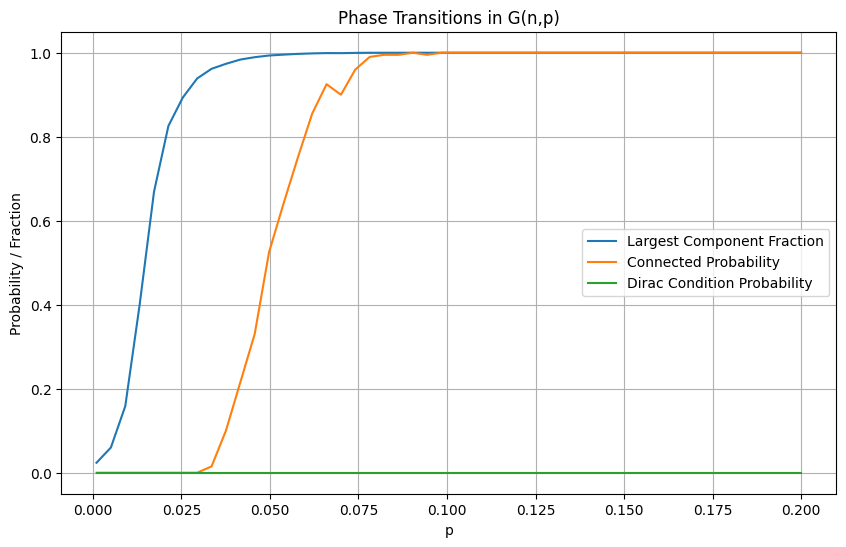

In [ ]:
n = 100

p_values = np.linspace(0.001, 0.2, 50)

giant, connected, dirac = monte_carlo(
    n,
    p_values,
    trials=200
)

plot_results(p_values, giant, connected, dirac)